# SECOM Dataset - Feature Engineering

**Project**: Semiconductor Manufacturing Yield Prediction  
**Phase**: Feature Engineering  
**Goal**: Transform raw features into model-ready datasets

## Overview

Based on EDA insights, this notebook implements:
1. Feature cleaning (remove high missing, zero variance)
2. Missing value imputation (adaptive strategy)
3. Feature transformations (handle skewness)
4. Feature scaling (standardization)
5. Feature selection (statistical methods)
6. Dimensionality reduction (PCA - optional)
7. Class imbalance handling (SMOTE)

## Table of Contents
1. [Setup & Data Loading](#1-setup-data-loading)
2. [Load EDA Recommendations](#2-load-eda-recommendations)
3. [Feature Cleaning](#3-feature-cleaning)
4. [Missing Value Imputation](#4-missing-value-imputation)
5. [Feature Transformation](#5-feature-transformation)
6. [Feature Scaling](#6-feature-scaling)
7. [Feature Selection](#7-feature-selection)
8. [PCA Analysis](#8-pca-analysis)
9. [Class Imbalance Handling](#9-class-imbalance-handling)
10. [Save Engineered Datasets](#10-save-engineered-datasets)
11. [Summary](#11-summary)

## 1. Setup & Data Loading

In [1]:
import sys
from pathlib import Path

# Add project root to path
project_root = Path().absolute().parent
sys.path.append(str(project_root))

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from scipy import stats
import warnings

# Custom modules
from src.data.data_loader import SECOMDataLoader
from src.features.feature_engineering import SECOMFeatureEngineer, create_full_pipeline

# Settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)

%matplotlib inline

# Random seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Setup complete!")

Setup complete!


In [2]:
# Load data
loader = SECOMDataLoader(data_dir="../data/raw")
features, labels, timestamps = loader.load_data()

print(f"Loaded dataset:")
print(f"  Features: {features.shape}")
print(f"  Labels: {labels.shape}")
print(f"  Failure rate: {labels.mean():.2%}")

Loaded dataset:
  Features: (1567, 590)
  Labels: (1567,)
  Failure rate: 6.64%


In [3]:
# Create train/val/test splits
splits = loader.train_test_split(
    test_size=0.2,
    validation_size=0.1,
    random_state=RANDOM_STATE,
    stratify=True
)

X_train, X_val, X_test, y_train, y_val, y_test = splits

print("\nData splits:")
print(f"  Train: {X_train.shape[0]} samples ({y_train.mean():.2%} failure rate)")
print(f"  Val:   {X_val.shape[0]} samples ({y_val.mean():.2%} failure rate)")
print(f"  Test:  {X_test.shape[0]} samples ({y_test.mean():.2%} failure rate)")


Data splits:
  Train: 1096 samples (6.66% failure rate)
  Val:   157 samples (6.37% failure rate)
  Test:  314 samples (6.69% failure rate)


## 2. Load EDA Recommendations

In [4]:
# Load EDA recommendations
with open('../reports/eda_recommendations.json', 'r') as f:
    eda_recommendations = json.load(f)

print("EDA Recommendations:")
print(f"  Features to remove: {len(eda_recommendations['features_to_remove'])}")
print(f"  Top discriminative features: {len(eda_recommendations['top_discriminative_features'])}")
print(f"  High correlation features: {len(eda_recommendations['high_correlation_features'])}")
print(f"  Features needing transformation: {len(eda_recommendations['features_need_transformation'])}")

EDA Recommendations:
  Features to remove: 148
  Top discriminative features: 20
  High correlation features: 20
  Features needing transformation: 19


## 3. Feature Cleaning

Remove features with high missing values and zero variance.

In [5]:
# Initialize feature engineer
engineer = SECOMFeatureEngineer(random_state=RANDOM_STATE)

# Step 1: Remove features with >40% missing values
print("Step 1: Removing high-missing features...")
print(f"  Initial features: {X_train.shape[1]}")

X_train_clean = engineer.remove_high_missing_features(X_train, threshold=40.0)
X_val_clean = X_val[X_train_clean.columns]
X_test_clean = X_test[X_train_clean.columns]

print(f"  After removing high-missing: {X_train_clean.shape[1]} features")
print(f"  Removed: {X_train.shape[1] - X_train_clean.shape[1]} features")

Step 1: Removing high-missing features...
  Initial features: 590
  After removing high-missing: 558 features
  Removed: 32 features


In [6]:
# Step 2: Remove zero-variance features
print("Step 2: Removing zero-variance features...")
print(f"  Current features: {X_train_clean.shape[1]}")

X_train_clean = engineer.remove_zero_variance_features(X_train_clean, threshold=0.0)
X_val_clean = X_val_clean[X_train_clean.columns]
X_test_clean = X_test_clean[X_train_clean.columns]

print(f"  After removing zero-variance: {X_train_clean.shape[1]} features")
print(f"  Total removed: {X_train.shape[1] - X_train_clean.shape[1]} features")

Step 2: Removing zero-variance features...
  Current features: 558
  After removing zero-variance: 436 features
  Total removed: 154 features


## 4. Missing Value Imputation

Use adaptive imputation strategy based on missing percentage.

In [7]:
# Check missing values before imputation
missing_before = X_train_clean.isna().sum().sum()
missing_pct_before = missing_before / (X_train_clean.shape[0] * X_train_clean.shape[1]) * 100

print(f"Missing values before imputation:")
print(f"  Total: {missing_before:,} ({missing_pct_before:.2f}%)")
print(f"  Features with missing: {X_train_clean.isna().any().sum()}")

Missing values before imputation:
  Total: 5,583 (1.17%)
  Features with missing: 352


In [8]:
# Apply adaptive imputation
print("\nApplying adaptive imputation strategy...")
print("  <5% missing: Simple median imputation")
print("  5-20% missing: KNN imputation")
print("  20-40% missing: Iterative imputation")

X_train_imputed = engineer.impute_missing_values(X_train_clean, strategy='auto')
X_val_imputed = engineer.impute_missing_values(X_val_clean, strategy='auto')
X_test_imputed = engineer.impute_missing_values(X_test_clean, strategy='auto')

# Verify no missing values
missing_after = X_train_imputed.isna().sum().sum()
print(f"\nMissing values after imputation: {missing_after}")
print("Imputation complete!")


Applying adaptive imputation strategy...
  <5% missing: Simple median imputation
  5-20% missing: KNN imputation
  20-40% missing: Iterative imputation

Missing values after imputation: 0
Imputation complete!


## 5. Feature Transformation

Apply power transformation to highly skewed features.

In [9]:
# Analyze skewness
skewness = X_train_imputed.skew()
highly_skewed = skewness[abs(skewness) > 2]

print(f"Skewness analysis:")
print(f"  Features with |skewness| > 2: {len(highly_skewed)}")
print(f"  Mean absolute skewness: {abs(skewness).mean():.2f}")
print(f"  Max skewness: {skewness.max():.2f}")
print(f"  Min skewness: {skewness.min():.2f}")

Skewness analysis:
  Features with |skewness| > 2: 231
  Mean absolute skewness: 6.04
  Max skewness: 33.11
  Min skewness: -21.50


In [10]:
# Apply Yeo-Johnson transformation to skewed features
print("\nApplying power transformation to highly skewed features...")

X_train_transformed = engineer.transform_skewed_features(
    X_train_imputed, 
    skew_threshold=2.0, 
    method='yeo-johnson'
)
X_val_transformed = engineer.transform_skewed_features(
    X_val_imputed, 
    skew_threshold=2.0, 
    method='yeo-johnson'
)
X_test_transformed = engineer.transform_skewed_features(
    X_test_imputed, 
    skew_threshold=2.0, 
    method='yeo-johnson'
)

# Check skewness after transformation
skewness_after = X_train_transformed.skew()
highly_skewed_after = skewness_after[abs(skewness_after) > 2]

print(f"\nAfter transformation:")
print(f"  Features with |skewness| > 2: {len(highly_skewed_after)}")
print(f"  Mean absolute skewness: {abs(skewness_after).mean():.2f}")
print(f"  Improvement: {len(highly_skewed) - len(highly_skewed_after)} features normalized")


Applying power transformation to highly skewed features...

After transformation:
  Features with |skewness| > 2: 9
  Mean absolute skewness: 0.54
  Improvement: 222 features normalized


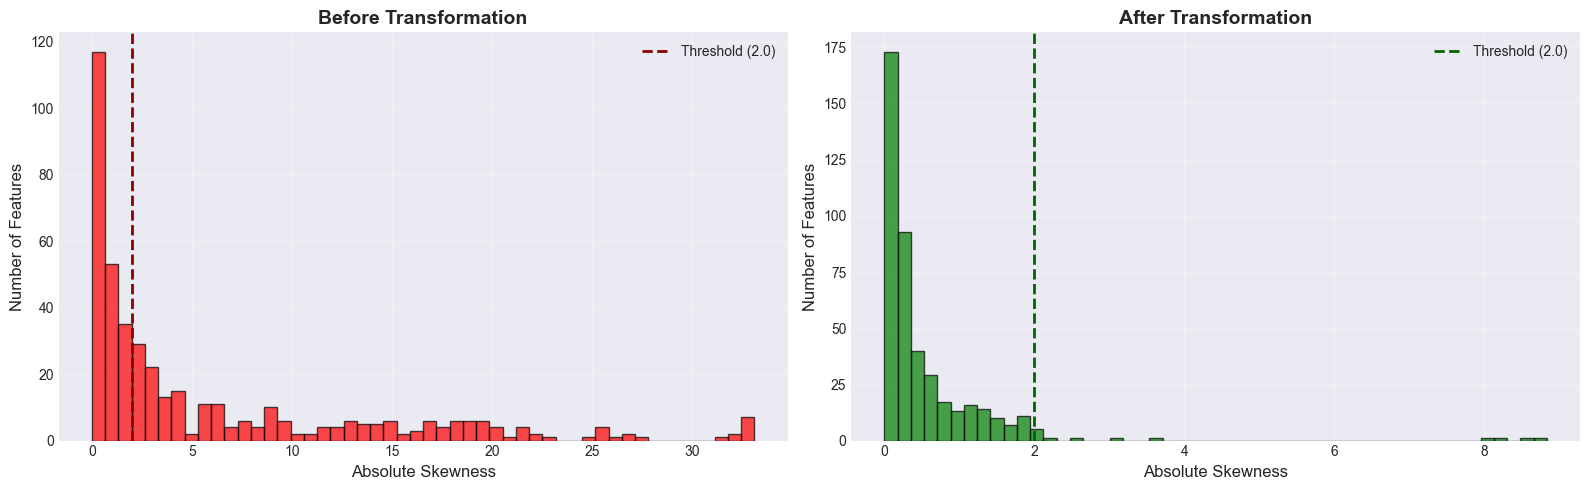

In [11]:
# Visualize skewness improvement
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Before transformation
axes[0].hist(abs(skewness), bins=50, edgecolor='black', alpha=0.7, color='red')
axes[0].axvline(2, color='darkred', linestyle='--', linewidth=2, label='Threshold (2.0)')
axes[0].set_xlabel('Absolute Skewness', fontsize=12)
axes[0].set_ylabel('Number of Features', fontsize=12)
axes[0].set_title('Before Transformation', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# After transformation
axes[1].hist(abs(skewness_after), bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].axvline(2, color='darkgreen', linestyle='--', linewidth=2, label='Threshold (2.0)')
axes[1].set_xlabel('Absolute Skewness', fontsize=12)
axes[1].set_ylabel('Number of Features', fontsize=12)
axes[1].set_title('After Transformation', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/fe_01_skewness_improvement.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Feature Scaling

Standardize features for distance-based algorithms.

In [12]:
# Apply standard scaling
print("Applying standard scaling...")

X_train_scaled = engineer.scale_features(X_train_transformed, method='standard')
X_val_scaled = engineer.scale_features(X_val_transformed, method='standard')
X_test_scaled = engineer.scale_features(X_test_transformed, method='standard')

print("\nScaling statistics:")
print(f"  Mean: {X_train_scaled.mean().mean():.6f}")
print(f"  Std: {X_train_scaled.std().mean():.6f}")
print("Standard scaling complete!")

Applying standard scaling...

Scaling statistics:
  Mean: -0.000000
  Std: 1.000457
Standard scaling complete!


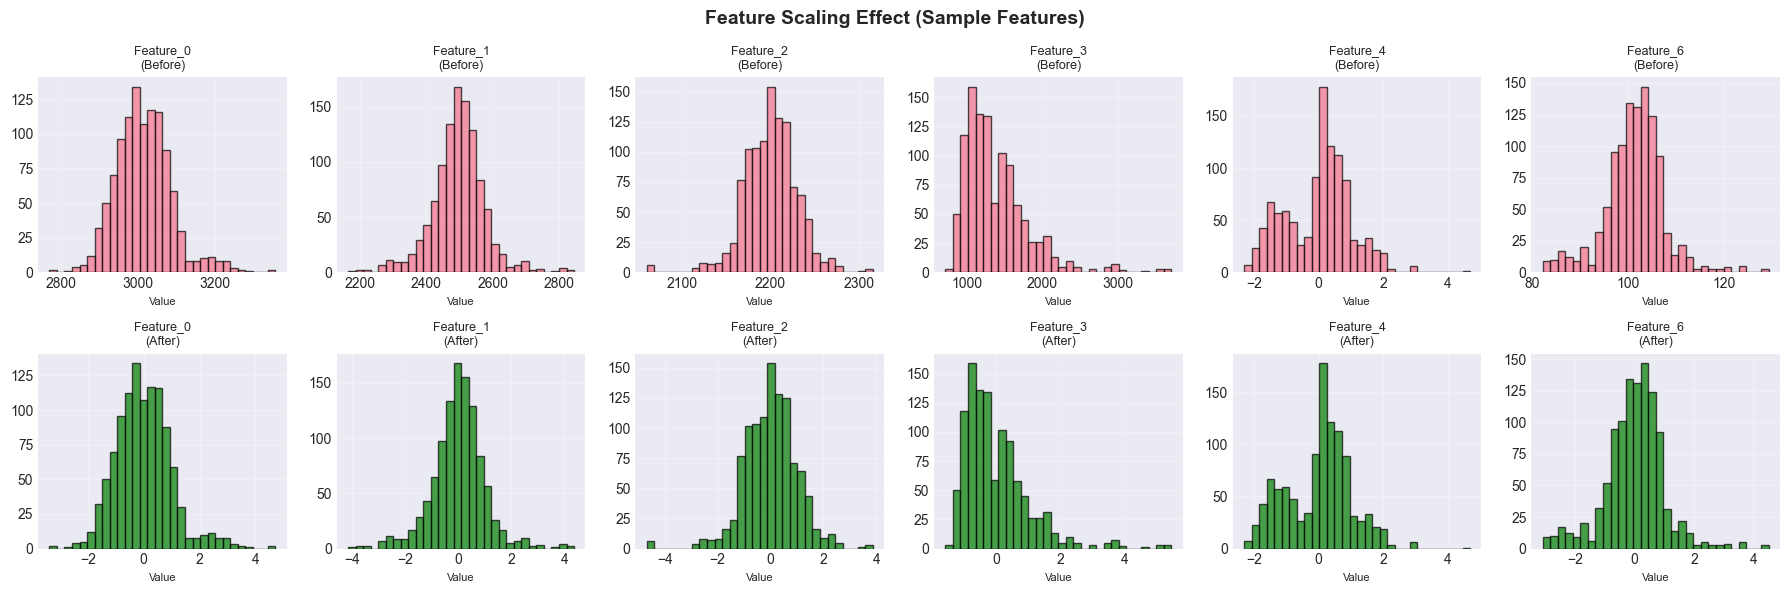

In [13]:
# Visualize scaling effect
sample_features = X_train_scaled.columns[:6].tolist()

fig, axes = plt.subplots(2, 6, figsize=(18, 6))

for i, feature in enumerate(sample_features):
    # Before scaling
    axes[0, i].hist(X_train_transformed[feature], bins=30, edgecolor='black', alpha=0.7)
    axes[0, i].set_title(f'{feature}\n(Before)', fontsize=9)
    axes[0, i].set_xlabel('Value', fontsize=8)
    axes[0, i].grid(alpha=0.3)
    
    # After scaling
    axes[1, i].hist(X_train_scaled[feature], bins=30, edgecolor='black', alpha=0.7, color='green')
    axes[1, i].set_title(f'{feature}\n(After)', fontsize=9)
    axes[1, i].set_xlabel('Value', fontsize=8)
    axes[1, i].grid(alpha=0.3)

plt.suptitle('Feature Scaling Effect (Sample Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/fe_02_scaling_effect.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Feature Selection

Select most important features using statistical tests.

In [14]:
# Select top K features
K_FEATURES = 100  # Adjust based on your needs

print(f"Selecting top {K_FEATURES} features using ANOVA F-test...")
print(f"  Current features: {X_train_scaled.shape[1]}")

X_train_selected = engineer.select_features(
    X_train_scaled, 
    y_train, 
    method='kbest', 
    k=K_FEATURES
)
X_val_selected = X_val_scaled[X_train_selected.columns]
X_test_selected = X_test_scaled[X_train_selected.columns]

print(f"  Selected features: {X_train_selected.shape[1]}")
print(f"  Reduction: {X_train_scaled.shape[1] - X_train_selected.shape[1]} features")

# Get feature scores
feature_scores = pd.DataFrame({
    'Feature': X_train_selected.columns,
    'Score': engineer.feature_selector.scores_[engineer.feature_selector.get_support()]
}).sort_values('Score', ascending=False)

print("\nTop 20 selected features:")
display(feature_scores.head(20))

Selecting top 100 features using ANOVA F-test...
  Current features: 436
  Selected features: 100
  Reduction: 336 features

Top 20 selected features:


,Feature,Score
22,Feature_103,36.304284
93,Feature_510,24.579083
89,Feature_477,18.724486
49,Feature_205,17.976051
8,Feature_59,17.464607
12,Feature_64,15.672078
3,Feature_33,15.134324
66,Feature_341,14.786321
33,Feature_129,12.586437
79,Feature_431,11.852653


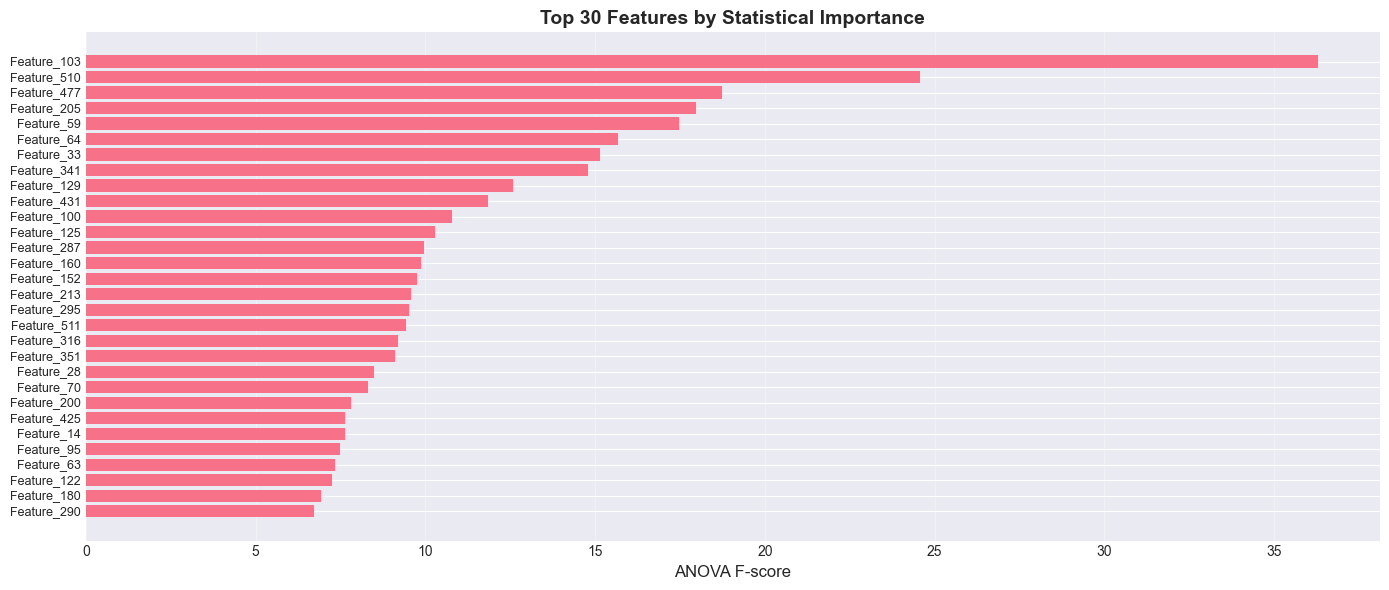

In [15]:
# Visualize feature scores
fig, ax = plt.subplots(figsize=(14, 6))

top_features = feature_scores.head(30)
ax.barh(range(len(top_features)), top_features['Score'])
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'], fontsize=9)
ax.set_xlabel('ANOVA F-score', fontsize=12)
ax.set_title(f'Top 30 Features by Statistical Importance', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../reports/figures/fe_03_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. PCA Analysis

Explore dimensionality reduction with PCA.

In [16]:
# Apply PCA to see variance explained
print("Applying PCA to analyze dimensionality...")

X_train_pca, pca = engineer.apply_pca(X_train_selected, n_components=0.95)

print(f"\nPCA Results:")
print(f"  Original features: {X_train_selected.shape[1]}")
print(f"  PCA components (95% variance): {X_train_pca.shape[1]}")
print(f"  Variance explained: {pca.explained_variance_ratio_.sum():.2%}")
print(f"  Dimensionality reduction: {X_train_selected.shape[1] - X_train_pca.shape[1]} features")

Applying PCA to analyze dimensionality...

PCA Results:
  Original features: 100
  PCA components (95% variance): 47
  Variance explained: 95.14%
  Dimensionality reduction: 53 features


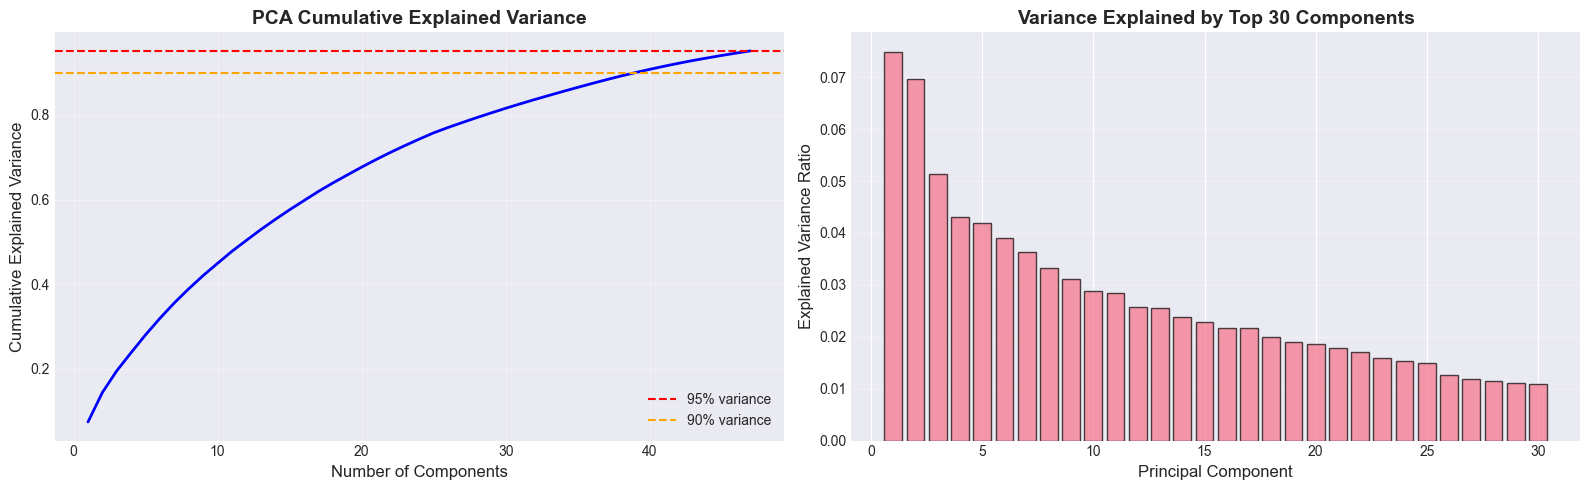


To preserve 95% variance, we need 47 components
To preserve 90% variance, we need 39 components
To preserve 99% variance, we need 1 components


In [17]:
# Visualize explained variance
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Cumulative variance explained
cumvar = np.cumsum(pca.explained_variance_ratio_)
axes[0].plot(range(1, len(cumvar) + 1), cumvar, 'b-', linewidth=2)
axes[0].axhline(0.95, color='red', linestyle='--', label='95% variance')
axes[0].axhline(0.90, color='orange', linestyle='--', label='90% variance')
axes[0].set_xlabel('Number of Components', fontsize=12)
axes[0].set_ylabel('Cumulative Explained Variance', fontsize=12)
axes[0].set_title('PCA Cumulative Explained Variance', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Individual variance per component
axes[1].bar(range(1, min(31, len(pca.explained_variance_ratio_) + 1)), 
            pca.explained_variance_ratio_[:30], 
            edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Principal Component', fontsize=12)
axes[1].set_ylabel('Explained Variance Ratio', fontsize=12)
axes[1].set_title('Variance Explained by Top 30 Components', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../reports/figures/fe_04_pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTo preserve 95% variance, we need {X_train_pca.shape[1]} components")
print(f"To preserve 90% variance, we need {np.argmax(cumvar >= 0.90) + 1} components")
print(f"To preserve 99% variance, we need {np.argmax(cumvar >= 0.99) + 1} components")

## 9. Class Imbalance Handling

Apply SMOTE to balance the training set.

In [18]:
# Check current class distribution
print("Class distribution BEFORE resampling:")
print(f"  Pass (0): {sum(y_train == 0)} ({sum(y_train == 0)/len(y_train):.2%})")
print(f"  Fail (1): {sum(y_train == 1)} ({sum(y_train == 1)/len(y_train):.2%})")
print(f"  Imbalance ratio: 1:{sum(y_train == 0)/sum(y_train == 1):.1f}")

Class distribution BEFORE resampling:
  Pass (0): 1023 (93.34%)
  Fail (1): 73 (6.66%)
  Imbalance ratio: 1:14.0


In [19]:
# Apply SMOTE
print("\nApplying SMOTE for class balancing...")

X_train_resampled, y_train_resampled = engineer.handle_class_imbalance(
    X_train_selected,
    y_train,
    method='smote',
    sampling_strategy='auto'  # Balance to 1:1 ratio
)

print("\nClass distribution AFTER resampling:")
print(f"  Pass (0): {sum(y_train_resampled == 0)} ({sum(y_train_resampled == 0)/len(y_train_resampled):.2%})")
print(f"  Fail (1): {sum(y_train_resampled == 1)} ({sum(y_train_resampled == 1)/len(y_train_resampled):.2%})")
print(f"  New ratio: 1:{sum(y_train_resampled == 0)/sum(y_train_resampled == 1):.1f}")
print(f"\nSamples added: {len(X_train_resampled) - len(X_train_selected)}")


Applying SMOTE for class balancing...

Class distribution AFTER resampling:
  Pass (0): 1023 (50.00%)
  Fail (1): 1023 (50.00%)
  New ratio: 1:1.0

Samples added: 950


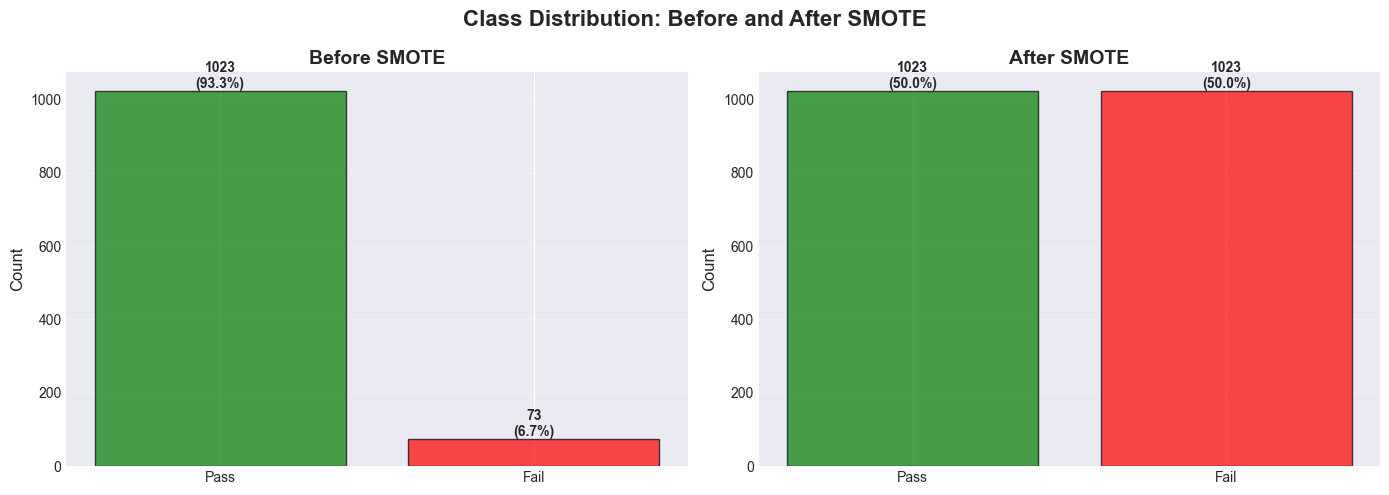

In [20]:
# Visualize class distribution before/after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before SMOTE
class_counts_before = y_train.value_counts()
axes[0].bar(['Pass', 'Fail'], [class_counts_before[0], class_counts_before[1]], 
            color=['green', 'red'], alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Before SMOTE', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate([class_counts_before[0], class_counts_before[1]]):
    axes[0].text(i, v, f'{v}\n({v/len(y_train):.1%})', ha='center', va='bottom', fontweight='bold')

# After SMOTE
class_counts_after = y_train_resampled.value_counts()
axes[1].bar(['Pass', 'Fail'], [class_counts_after[0], class_counts_after[1]], 
            color=['green', 'red'], alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('After SMOTE', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate([class_counts_after[0], class_counts_after[1]]):
    axes[1].text(i, v, f'{v}\n({v/len(y_train_resampled):.1%})', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Class Distribution: Before and After SMOTE', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/fe_05_smote_effect.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Save Engineered Datasets

Save both versions (with and without SMOTE) for modeling.

In [21]:
# Create engineered data directory
from pathlib import Path
output_dir = Path('../data/engineered')
output_dir.mkdir(parents=True, exist_ok=True)

print("Saving engineered datasets...")

Saving engineered datasets...


In [22]:
# Save WITHOUT SMOTE (for validation/test, and models that handle imbalance internally)
print("\n1. Datasets WITHOUT SMOTE:")

# Training set (no SMOTE)
train_no_smote = X_train_selected.copy()
train_no_smote['Label'] = y_train.values
train_no_smote.to_csv(output_dir / 'train_engineered.csv', index=False)
print(f"   Saved: train_engineered.csv ({train_no_smote.shape[0]} samples, {train_no_smote.shape[1]-1} features)")

# Validation set
val_data = X_val_selected.copy()
val_data['Label'] = y_val.values
val_data.to_csv(output_dir / 'val_engineered.csv', index=False)
print(f"   Saved: val_engineered.csv ({val_data.shape[0]} samples, {val_data.shape[1]-1} features)")

# Test set
test_data = X_test_selected.copy()
test_data['Label'] = y_test.values
test_data.to_csv(output_dir / 'test_engineered.csv', index=False)
print(f"   Saved: test_engineered.csv ({test_data.shape[0]} samples, {test_data.shape[1]-1} features)")


1. Datasets WITHOUT SMOTE:
   Saved: train_engineered.csv (1096 samples, 100 features)
   Saved: val_engineered.csv (157 samples, 100 features)
   Saved: test_engineered.csv (314 samples, 100 features)


In [23]:
# Save WITH SMOTE (for models that benefit from balanced data)
print("\n2. Training set WITH SMOTE:")

train_smote = X_train_resampled.copy()
train_smote['Label'] = y_train_resampled.values
train_smote.to_csv(output_dir / 'train_engineered_smote.csv', index=False)
print(f"   Saved: train_engineered_smote.csv ({train_smote.shape[0]} samples, {train_smote.shape[1]-1} features)")


2. Training set WITH SMOTE:
   Saved: train_engineered_smote.csv (2046 samples, 100 features)


In [24]:
# Save PCA versions (optional - for comparison)
print("\n3. PCA versions (95% variance):")

# Apply PCA to all sets
from sklearn.decomposition import PCA

pca_final = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_train_pca_final = pca_final.fit_transform(X_train_selected)
X_val_pca_final = pca_final.transform(X_val_selected)
X_test_pca_final = pca_final.transform(X_test_selected)

# Save PCA datasets
n_components = X_train_pca_final.shape[1]
pca_columns = [f'PC_{i+1}' for i in range(n_components)]

train_pca = pd.DataFrame(X_train_pca_final, columns=pca_columns)
train_pca['Label'] = y_train.values
train_pca.to_csv(output_dir / 'train_engineered_pca.csv', index=False)

val_pca = pd.DataFrame(X_val_pca_final, columns=pca_columns)
val_pca['Label'] = y_val.values
val_pca.to_csv(output_dir / 'val_engineered_pca.csv', index=False)

test_pca = pd.DataFrame(X_test_pca_final, columns=pca_columns)
test_pca['Label'] = y_test.values
test_pca.to_csv(output_dir / 'test_engineered_pca.csv', index=False)

print(f"   Saved PCA datasets with {n_components} components")


3. PCA versions (95% variance):
   Saved PCA datasets with 47 components


In [27]:
# Save feature engineering summary with proper type conversion
summary = engineer.get_feature_importance_summary()
summary['selected_features'] = X_train_selected.columns.tolist()
summary['n_features_final'] = int(len(X_train_selected.columns))
summary['n_samples_original'] = int(len(X_train))
summary['n_samples_smote'] = int(len(X_train_resampled))

# Convert any numpy types to native Python types
def convert_to_native_types(obj):
    if isinstance(obj, dict):
        return {k: convert_to_native_types(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_native_types(item) for item in obj]
    elif isinstance(obj, (np.integer, np.int64, np.int32)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float64, np.float32)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

summary = convert_to_native_types(summary)

with open('../reports/feature_engineering_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("\n4. Feature engineering summary saved!")
print("\n" + "="*80)
print("ALL ENGINEERED DATASETS SAVED SUCCESSFULLY!")
print("="*80)


4. Feature engineering summary saved!

ALL ENGINEERED DATASETS SAVED SUCCESSFULLY!


## 11. Summary

Feature engineering pipeline complete!

In [26]:
print("="*80)
print("FEATURE ENGINEERING SUMMARY")
print("="*80)

print("\n1. FEATURE REDUCTION")
print(f"   Original features: {features.shape[1]}")
print(f"   After cleaning: {X_train_clean.shape[1]} (removed {features.shape[1] - X_train_clean.shape[1]})")
print(f"   After selection: {X_train_selected.shape[1]} (removed {X_train_clean.shape[1] - X_train_selected.shape[1]})")
print(f"   Total reduction: {features.shape[1] - X_train_selected.shape[1]} features ({(1 - X_train_selected.shape[1]/features.shape[1])*100:.1f}%)")

print("\n2. MISSING VALUE HANDLING")
print(f"   Before: {missing_before:,} missing values ({missing_pct_before:.2f}%)")
print(f"   After: 0 missing values (100% complete)")

print("\n3. TRANSFORMATIONS APPLIED")
print(f"   Skewness correction: {len(highly_skewed)} features transformed")
print(f"   Scaling: StandardScaler applied to all features")
print(f"   Feature selection: Top {K_FEATURES} features selected")

print("\n4. CLASS IMBALANCE HANDLING")
print(f"   Original ratio: 1:{sum(y_train == 0)/sum(y_train == 1):.1f} (Pass:Fail)")
print(f"   After SMOTE: 1:1.0 (balanced)")
print(f"   Synthetic samples created: {len(X_train_resampled) - len(X_train_selected)}")

print("\n5. DATASETS SAVED")
print(f"   data/engineered/train_engineered.csv ({len(X_train_selected)} samples)")
print(f"   data/engineered/train_engineered_smote.csv ({len(X_train_resampled)} samples)")
print(f"   data/engineered/val_engineered.csv ({len(X_val_selected)} samples)")
print(f"   data/engineered/test_engineered.csv ({len(X_test_selected)} samples)")
print(f"   data/engineered/*_pca.csv ({n_components} PCA components)")

print("\n6. RECOMMENDED NEXT STEPS")
print("   1. Build baseline models (Logistic Regression, Decision Tree)")
print("   2. Train advanced models (Random Forest, XGBoost, LightGBM)")
print("   3. Compare performance with/without SMOTE")
print("   4. Try PCA versions for faster training")
print("   5. Use MLflow for experiment tracking")

print("\n" + "="*80)
print("FEATURE ENGINEERING COMPLETE!")
print("Ready for modeling phase...")
print("="*80)

FEATURE ENGINEERING SUMMARY

1. FEATURE REDUCTION
   Original features: 590
   After cleaning: 436 (removed 154)
   After selection: 100 (removed 336)
   Total reduction: 490 features (83.1%)

2. MISSING VALUE HANDLING
   Before: 5,583 missing values (1.17%)
   After: 0 missing values (100% complete)

3. TRANSFORMATIONS APPLIED
   Skewness correction: 231 features transformed
   Scaling: StandardScaler applied to all features
   Feature selection: Top 100 features selected

4. CLASS IMBALANCE HANDLING
   Original ratio: 1:14.0 (Pass:Fail)
   After SMOTE: 1:1.0 (balanced)
   Synthetic samples created: 950

5. DATASETS SAVED
   data/engineered/train_engineered.csv (1096 samples)
   data/engineered/train_engineered_smote.csv (2046 samples)
   data/engineered/val_engineered.csv (157 samples)
   data/engineered/test_engineered.csv (314 samples)
   data/engineered/*_pca.csv (47 PCA components)

6. RECOMMENDED NEXT STEPS
   1. Build baseline models (Logistic Regression, Decision Tree)
   2. T